In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft,fftfreq

# Q1.a

In [2]:
fs = 1000
duration=2
freq_sine = 50

In [3]:
t = np.linspace(0, duration, fs * duration, endpoint=False)
x = np.sin(2 * np.pi * freq_sine * t)

In [7]:
N = len(x)
yf = fft(x)
xf = fftfreq(N, 1 / fs)

In [8]:
half_N = N // 2
xf_plot = xf[:half_N]
yf_plot = 2.0 / N * np.abs(yf[:half_N])

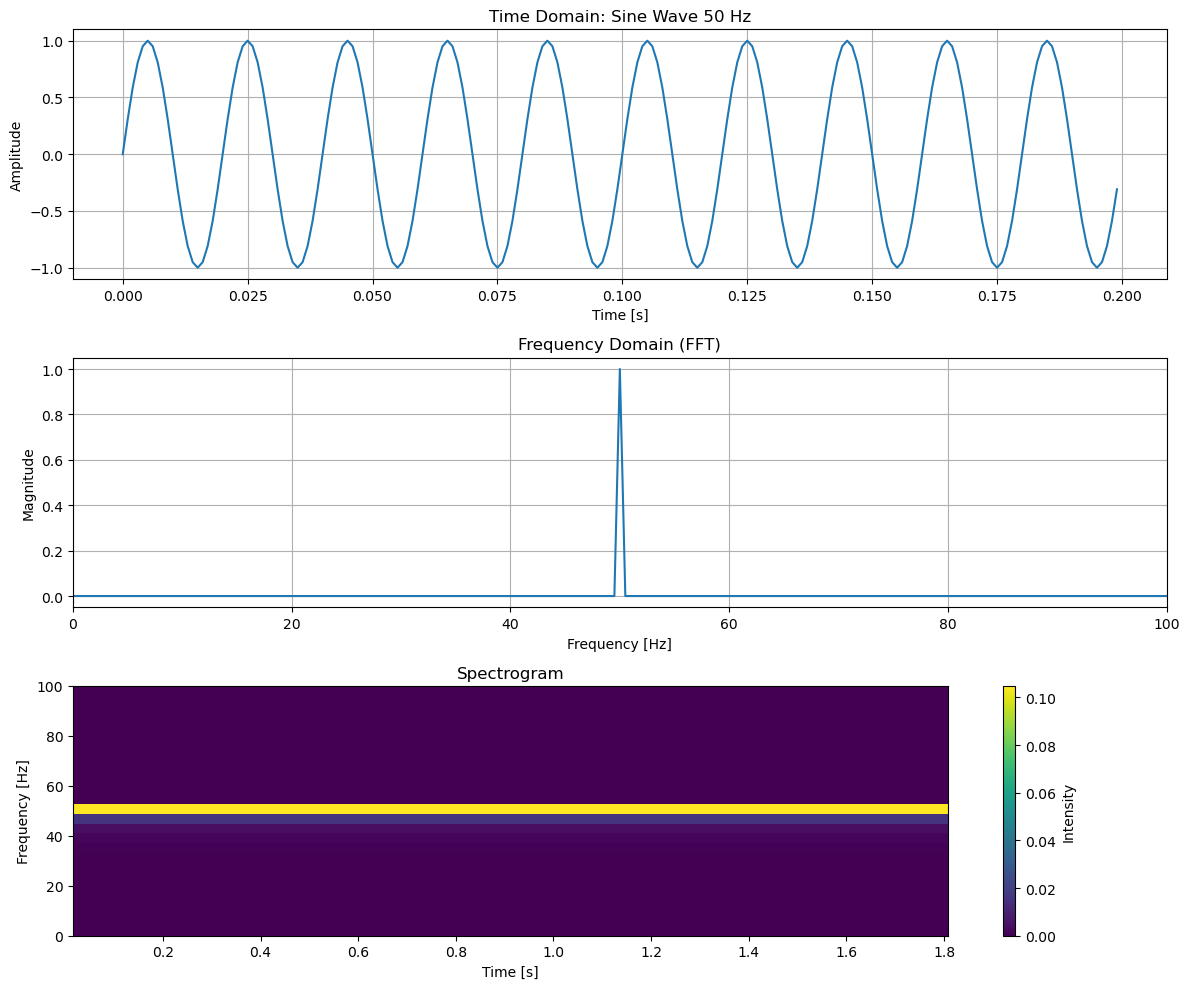

In [13]:
plt.figure(figsize=(12, 10))

# Time Domain Plot
plt.subplot(3, 1, 1)
plt.plot(t[:200], x[:200]) # Plotting first 0.2s for visibility
plt.title(f'Time Domain: Sine Wave {freq_sine} Hz')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Frequency Domain Plot
plt.subplot(3, 1, 2)
plt.plot(xf_plot, yf_plot)
plt.title('Frequency Domain (FFT)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 100) # Limiting x-axis to zoom in on the relevant frequency

# Spectrogram
plt.subplot(3, 1, 3)
f, t_spec, Sxx = signal.spectrogram(x, fs)
plt.pcolormesh(t_spec, f, Sxx)
plt.title('Spectrogram')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 100)
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

# Q1.b

In [89]:
fs = 10000           # Sampling frequency
duration = 2        # Duration
fc = 100            # Carrier frequency (Center frequency)
fm = 5              # Modulation frequency (Rate of change)
beta = 5            # Modulation index (Depth of change)

In [90]:
t = np.linspace(0, duration, fs * duration, endpoint=False)
# Formula: sin(2*pi*fc*t + beta*sin(2*pi*fm*t))
x = np.sin(2 * np.pi * fc * t + beta * np.sin(2 * np.pi * fm * t))

In [91]:
N = len(x)
yf = fft(x)
xf = fftfreq(N, 1 / fs)

half_N = N // 2
xf_plot = xf[:half_N]
yf_plot = 2.0 / N * np.abs(yf[:half_N])

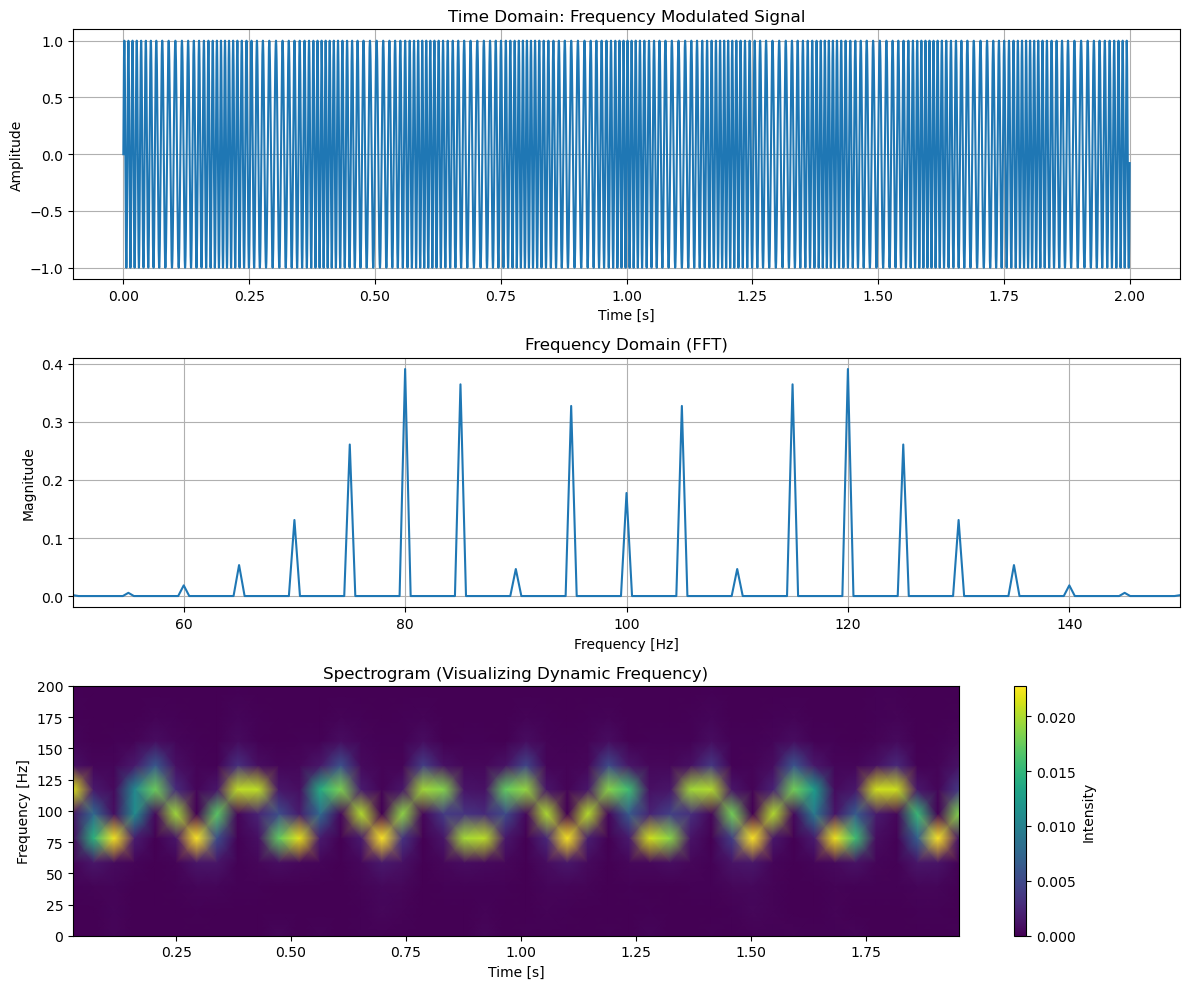

In [92]:
plt.figure(figsize=(12, 10))

# Time Domain
plt.subplot(3, 1, 1)
plt.plot(t, x) # Zoom in to see the wave compression/expansion
plt.title('Time Domain: Frequency Modulated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Frequency Domain
plt.subplot(3, 1, 2)
plt.plot(xf_plot, yf_plot)
plt.title('Frequency Domain (FFT)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(50, 150) # Zoom around carrier frequency

# Spectrogram
plt.subplot(3, 1, 3)
# Nperseg controls the resolution trade-off between time and frequency
f, t_spec, Sxx = signal.spectrogram(x, fs, nperseg=512)
plt.pcolormesh(t_spec, f, Sxx, shading='gouraud')
plt.title('Spectrogram (Visualizing Dynamic Frequency)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 200)
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

# Q1.c)

In [34]:
fs = 1000       # Sampling frequency
duration = 2    # Duration
f_start = 20    # Starting frequency (Hz)
f_end = 200     # Ending frequency (Hz)

In [35]:
t = np.linspace(0, duration, fs * duration, endpoint=False)
# method='linear' creates a linear frequency sweep
x = signal.chirp(t, f0=f_start, f1=f_end, t1=duration, method='linear')

In [36]:
N = len(x)
yf = fft(x)
xf = fftfreq(N, 1 / fs)

half_N = N // 2
xf_plot = xf[:half_N]
yf_plot = 2.0 / N * np.abs(yf[:half_N])

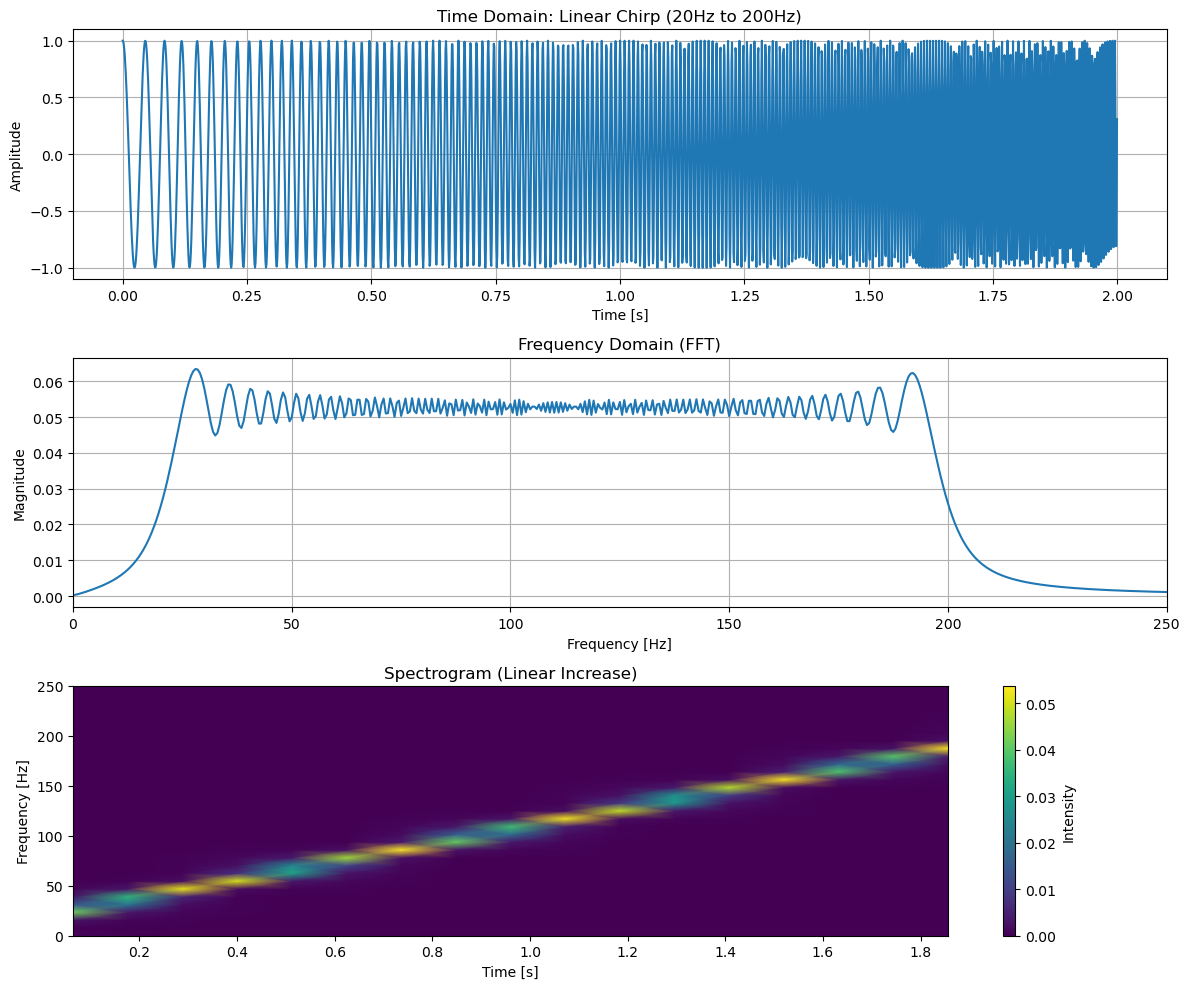

In [37]:
plt.figure(figsize=(12, 10))

# Time Domain
plt.subplot(3, 1, 1)
plt.plot(t, x)
plt.title(f'Time Domain: Linear Chirp ({f_start}Hz to {f_end}Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Frequency Domain
plt.subplot(3, 1, 2)
plt.plot(xf_plot, yf_plot)
plt.title('Frequency Domain (FFT)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.grid(True)
plt.xlim(0, 250)

# Spectrogram
plt.subplot(3, 1, 3)
f, t_spec, Sxx = signal.spectrogram(x, fs, nperseg=128)
plt.pcolormesh(t_spec, f, Sxx, shading='gouraud')
plt.title('Spectrogram (Linear Increase)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 250)
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

# Q2

In [40]:
import sounddevice as sd

In [81]:
fs = 44100      # Sampling frequency (Standard for audio)
duration = 10    # Duration of recording (seconds)

In [82]:
print("Recording... Speak now!")
 
# --- 1. Recording ---
# sd.rec records the audio in the background
recording = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype='float64')
sd.wait()  # Wait until recording is finished
print("Recording finished.")

Recording... Speak now!
Recording finished.


In [83]:
x = recording.flatten()
N = len(x)
yf = fft(x)
xf = fftfreq(N, 1 / fs)

# Get positive half of the spectrum
half_N = N // 2
xf_plot = xf[:half_N]
yf_plot = 2.0 / N * np.abs(yf[:half_N])

In [84]:
print("Playing back the recording...")
sd.play(x, fs)
sd.wait() # Important: Wait for the playback to finish before exiting
print("Playback finished.")

Playing back the recording...
Playback finished.


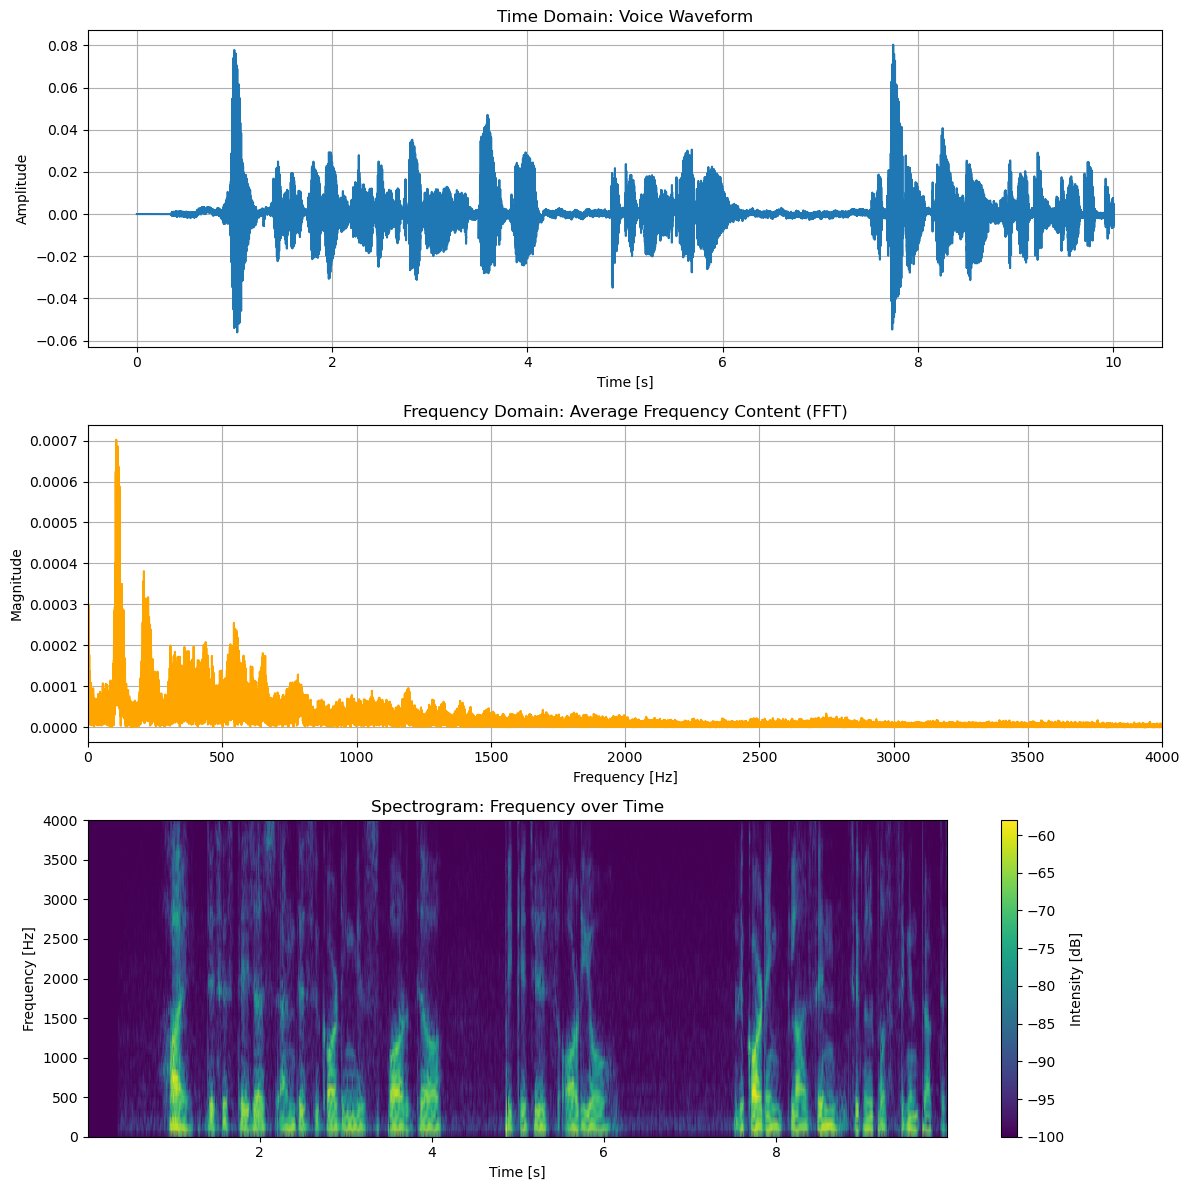

In [87]:
plt.figure(figsize=(12, 12)) # Increased height for 3 plots

# Plot 1: Time Domain
plt.subplot(3, 1, 1)
t = np.linspace(0, duration, len(x))
plt.plot(t, x)
plt.title('Time Domain: Voice Waveform')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(True)

# Plot 2: Frequency Domain (FFT)
plt.subplot(3, 1, 2)
plt.plot(xf_plot, yf_plot, color='orange')
plt.title('Frequency Domain: Average Frequency Content (FFT)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.xlim(0, 4000) # Zooming in to 0-4kHz (Human voice range)
plt.grid(True)

# Plot 3: Spectrogram
plt.subplot(3, 1, 3)
f, t_spec, Sxx = signal.spectrogram(x, fs, nperseg=512)
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud')
plt.title('Spectrogram: Frequency over Time')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.ylim(0, 4000)
plt.colorbar(label='Intensity [dB]')

plt.tight_layout()
plt.show()